# Bike Sharing Demand Prediction

This notebook builds and evaluates regression models for predicting hourly bike-sharing demand.

The models are evaluated using a chronological train/test split to avoid using future observations during training.

Models:

- Mean Baseline
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Evaluation metrics:

- MAE
- RMSE
- R²

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data_processing import load_and_prepare_data
from src.feature_engineering import create_features
from src.modeling import (
    build_models,
    calculate_metrics,
    evaluate_baseline,
    evaluate_models,
    get_feature_importance,
    get_predictions,
    split_data,
    train_models,
)

## 1. Load and Prepare the Data

In [2]:
DATA_PATH = Path("../data/raw/hour.csv")

df = load_and_prepare_data(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Create the Final Feature Matrix

The feature engineering module creates the final 14 predictors and separates them from the target variable `cnt`.

In [3]:
X, y = create_features(df)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (17379, 14)
Target shape: (17379,)

Features:
['season', 'holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'year', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'is_rush_hour']


## 3. Time-Based Train/Test Split

Because bike-sharing demand is time-dependent, the observations are kept in chronological order.

The first 80% of observations are used for training and the final 20% are used for testing.

This prevents future observations from being used to train the model.

In [4]:
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (13903, 14) (13903,)
Test set: (3476, 14) (3476,)


In [5]:
print("Training period:")
print(df["dteday"].iloc[:len(X_train)].min())
print(df["dteday"].iloc[:len(X_train)].max())

print("\nTest period:")
print(df["dteday"].iloc[len(X_train):].min())
print(df["dteday"].iloc[len(X_train):].max())

Training period:
2011-01-01 00:00:00
2012-08-07 00:00:00

Test period:
2012-08-07 00:00:00
2012-12-31 00:00:00


## 4. Mean Baseline

Before evaluating machine learning models, a simple baseline is established.

The baseline predicts the mean bike demand observed in the training set for every test observation.

A useful model should substantially outperform this baseline.

In [6]:
baseline_metrics = evaluate_baseline(
    y_train,
    y_test,
)

baseline_results = pd.DataFrame(
    [
        {
            "Model": "Mean Baseline",
            **baseline_metrics,
        }
    ]
)

baseline_results

,Model,MAE,RMSE,R2
0,Mean Baseline,174.984601,232.608375,-0.112995


## 5. Train Regression Models

Three regression models are evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Preprocessing is handled inside scikit-learn pipelines so that transformations are fitted only on the training data.

In [7]:
models = build_models()

trained_models = train_models(
    models,
    X_train,
    y_train,
)

print("Trained models:")
for name in trained_models:
    print("-", name)

Trained models:
- Linear Regression
- Decision Tree
- Random Forest


## 6. Model Evaluation

The models are evaluated on the unseen test set using:

- MAE: average absolute prediction error.
- RMSE: penalizes larger errors more strongly.
- R²: proportion of target variance explained by the model.

In [8]:
model_results = evaluate_models(
    trained_models,
    X_test,
    y_test,
)

model_results

,Model,MAE,RMSE,R2
0,Random Forest,54.903726,81.099362,0.864706
1,Decision Tree,67.544879,105.007184,0.773180
2,Linear Regression,98.788144,133.964405,0.630834


In [9]:
results = pd.concat(
    [
        baseline_results,
        model_results,
    ],
    ignore_index=True,
)

results.sort_values(
    "RMSE",
    ascending=True,
).reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Random Forest,54.903726,81.099362,0.864706
1,Decision Tree,67.544879,105.007184,0.773180
2,Linear Regression,98.788144,133.964405,0.630834
3,Mean Baseline,174.984601,232.608375,-0.112995


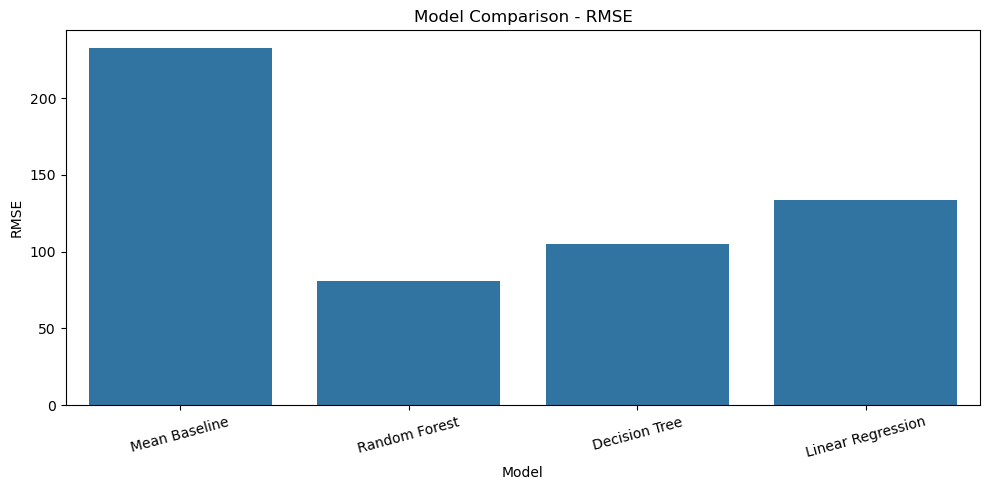

In [10]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE",
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

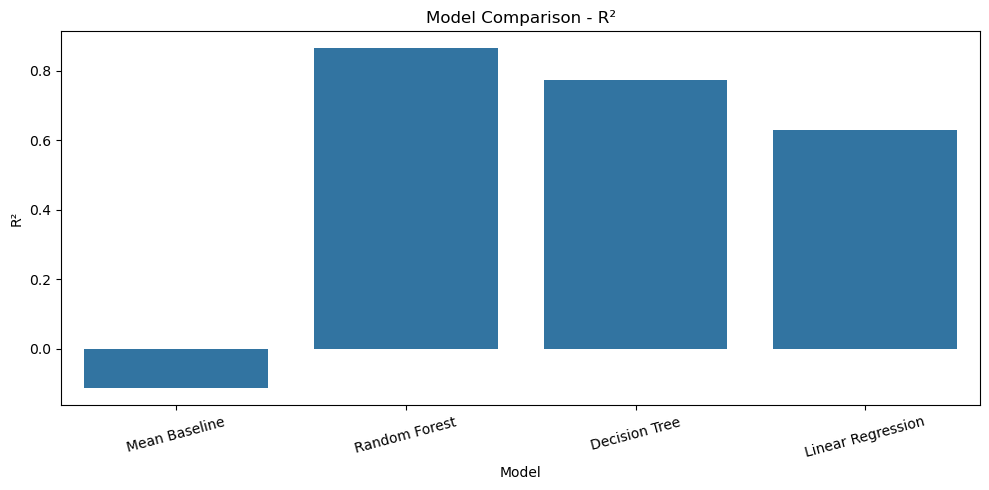

In [11]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2",
)

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

## 7. Best Performing Model

The best model is selected based on the lowest RMSE on the test set.

In [12]:
best_model_name = (
    model_results
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


## 8. Actual vs Predicted Demand

The following plot compares actual bike rentals with predictions from the best-performing model.

Points closer to the diagonal indicate more accurate predictions.

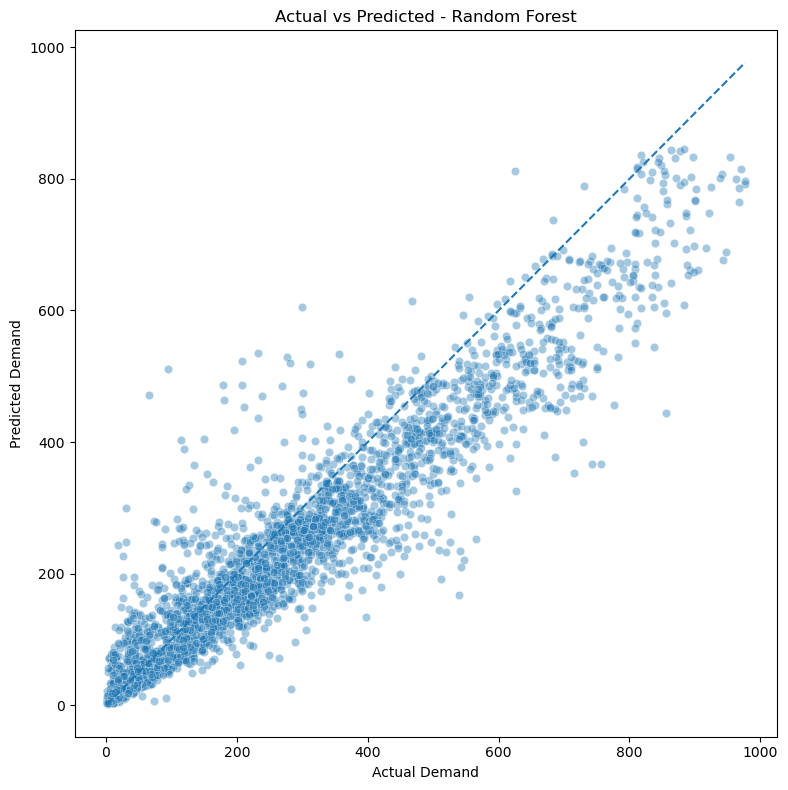

In [13]:
predictions = get_predictions(
    best_model,
    X_test,
)

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=predictions,
    alpha=0.4,
)

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
)

plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.tight_layout()

plt.show()

## 9. Residual Analysis

Residuals represent the difference between actual and predicted demand.

Analyzing residuals helps identify systematic prediction errors that may not be visible from a single performance metric.

In [14]:
residuals = y_test - predictions

residuals.describe()

count    3476.000000
mean       33.718904
std        73.767930
min      -417.640000
25%        -2.646250
50%        19.470000
75%        67.180000
max       411.035000
Name: cnt, dtype: float64

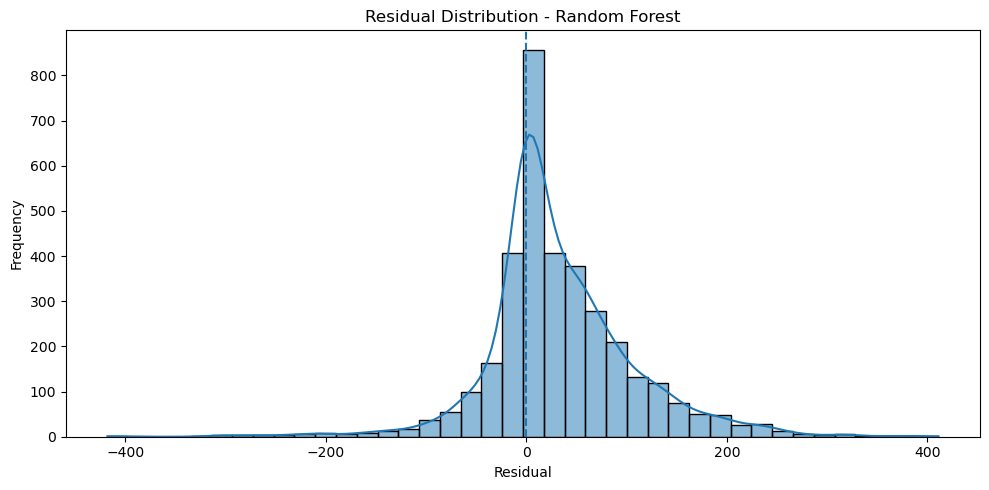

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

In [16]:
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = predictions
error_analysis["absolute_error"] = (
    error_analysis["actual"] - error_analysis["predicted"]
).abs()

error_analysis[
    [
        "hour",
        "workingday",
        "weathersit",
        "temp",
        "hum",
        "actual",
        "predicted",
        "absolute_error",
    ]
].sort_values(
    "absolute_error",
    ascending=False,
).head(10)

,hour,workingday,weathersit,temp,hum,actual,predicted,absolute_error
16454,8,1,1,0.24,0.87,94,511.640,417.640
15228,17,1,3,0.56,0.60,856,444.965,411.035
17196,8,1,1,0.22,0.69,66,471.460,405.460
14695,12,0,1,0.66,0.47,757,366.550,390.450
15470,19,1,1,0.44,0.51,743,367.415,375.585
16190,8,0,1,0.42,0.82,540,168.180,371.820
15252,17,1,3,0.62,0.88,715,353.350,361.650
16819,14,0,2,0.40,0.87,542,210.335,331.665
16621,8,1,2,0.22,0.80,729,400.470,328.530
16818,13,0,2,0.40,0.87,547,220.550,326.450


## 10. Feature Importance

Tree-based models provide feature importance scores that indicate how much each transformed feature contributes to the model's predictions.

The feature importance is examined for the best tree-based model.

In [17]:
if best_model_name in {"Decision Tree", "Random Forest"}:
    importance_df = get_feature_importance(best_model)

    importance_df.head(15)
else:
    print(
        "The best model is not a tree-based model. "
        "Feature importance is not available."
    )

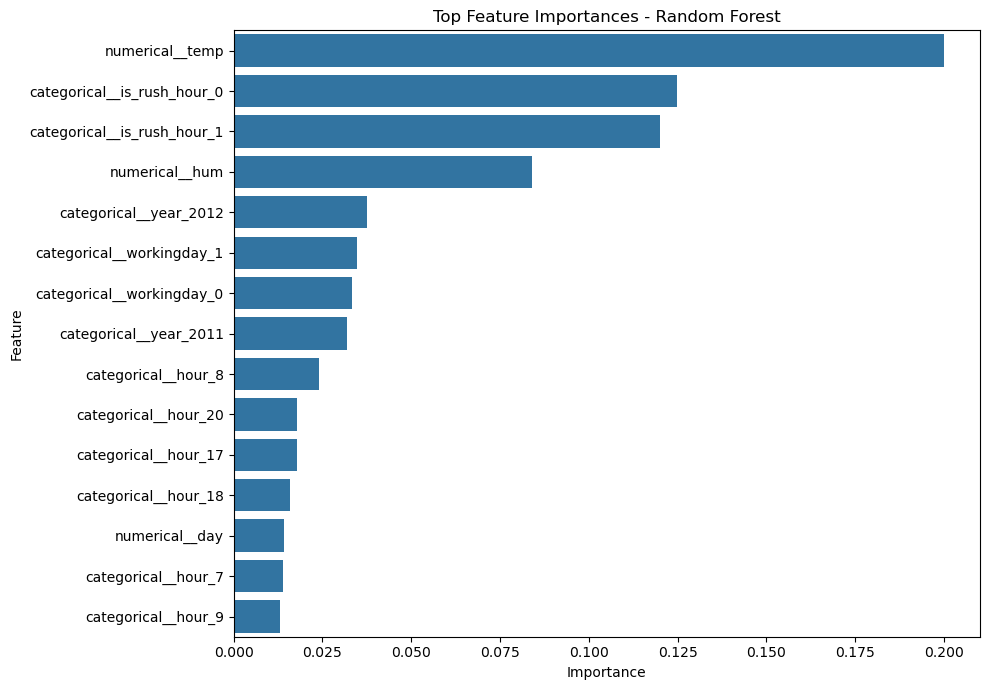

In [18]:
if best_model_name in {"Decision Tree", "Random Forest"}:
    top_features = importance_df.head(15)

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature",
    )

    plt.title(
        f"Top Feature Importances - {best_model_name}"
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.show()

In [19]:
best_result = (
    model_results[
        model_results["Model"] == best_model_name
    ]
    .iloc[0]
)

print(f"Best model: {best_model_name}")
print(f"MAE: {best_result['MAE']:.2f}")
print(f"RMSE: {best_result['RMSE']:.2f}")
print(f"R²: {best_result['R2']:.3f}")

Best model: Random Forest
MAE: 54.90
RMSE: 81.10
R²: 0.865


## Conclusion

The final model comparison shows how different regression approaches perform when predicting hourly bike-sharing demand.

The analysis compares a simple baseline with linear and tree-based models using a chronological test set.

The final interpretation will focus on:

- Which model provides the most accurate predictions.
- Which temporal and weather-related features are most influential.
- Where prediction errors are largest.
- How these findings can support bike-sharing demand planning and operational capacity decisions.

## Export Selected Figures

The following figures are exported for the final project report and GitHub repository.

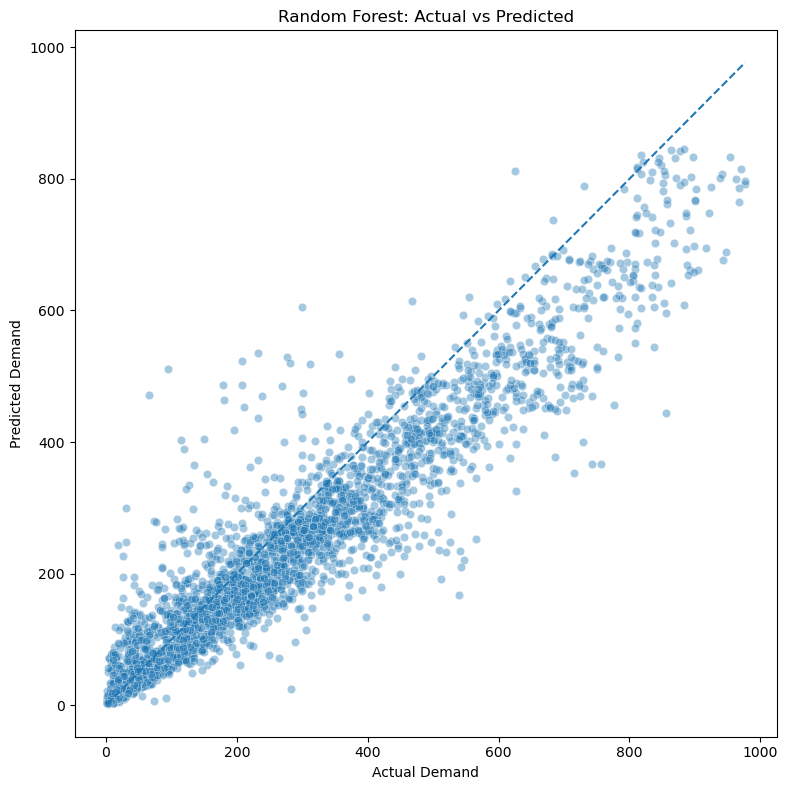

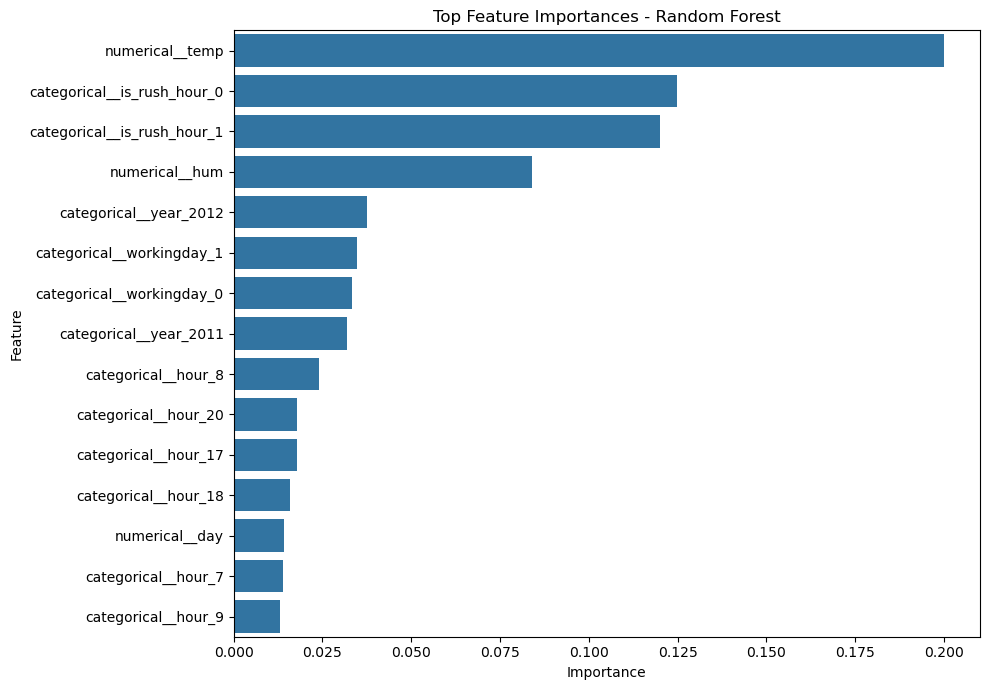

In [20]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.visualization import (
    plot_actual_vs_predicted,
    plot_feature_importance,
)


plot_actual_vs_predicted(
    y_test,
    predictions,
    title="Random Forest: Actual vs Predicted",
    save_path="../reports/figures/actual_vs_predicted.png",
)

plot_feature_importance(
    importance_df,
    top_n=15,
    title="Top Feature Importances - Random Forest",
    save_path="../reports/figures/feature_importance.png",
)